# **PARTE I: MODELADO Y CONEXIÓN A MONGODB**

In [1]:
!pip install pymongo dnspython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 23.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
from pymongo import MongoClient
import urllib.parse

# 1. CONEXIÓN A MONGODB ATLAS
username = urllib.parse.quote_plus('joseua1831_db_user')
password = urllib.parse.quote_plus('YKNENJPrxzKhzLMu')
cluster = 'cluster0.g6rjbz6.mongodb.net'

uri = f"mongodb+srv://{username}:{password}@{cluster}/?retryWrites=true&w=majority"
client = MongoClient(uri)
db = client['ecommerce_db'] # Creamos la base de datos

print("Conectado a MongoDB!")

# 2. LECTURA DE CSV
df_fact = pd.read_csv('fact_table.csv', encoding='latin1')
df_trans = pd.read_csv('Trans_dim.csv', encoding='latin1')
df_customer = pd.read_csv('customer_dim.csv', encoding='latin1')
df_item = pd.read_csv('item_dim.csv', encoding='latin1')
df_store = pd.read_csv('store_dim.csv', encoding='latin1')
df_time = pd.read_csv('time_dim.csv', encoding='latin1')

# 3. LIMPIEZA PREVIA (Criterio de validación de datos)
# item_dim y fact_table tienen las columnas 'unit_price' y 'unit'.
# Para evitar duplicados al unir, eliminamos estas de item_dim (nos quedamos con las del fact table que son las reales de la transacción)
df_item = df_item.drop(columns=['unit_price', 'unit'])

# 4. CARGA 1: COLECCIÓN DE CLIENTES
coleccion_clientes = db['clientes']
coleccion_clientes.drop() # Limpiamos por si ejecutamos varias veces
clientes_dict = df_customer.to_dict("records")
coleccion_clientes.insert_many(clientes_dict)
print(f"✅ Se cargaron {len(clientes_dict)} clientes.")

# 5. CARGA 2: COLECCIÓN DE TIENDAS
coleccion_tiendas = db['tiendas']
coleccion_tiendas.drop()
tiendas_dict = df_store.to_dict("records")
coleccion_tiendas.insert_many(tiendas_dict)
print(f"✅ Se cargaron {len(tiendas_dict)} tiendas.")

# 6. CARGA 3: MODELADO DE LA COLECCIÓN DE TRANSACCIONES (Embebida)
# En lugar de subir tablas sueltas, "embebemos" el tiempo, pago y producto en la transacción

# Unimos Fact Table + Time
df_transacciones = df_fact.merge(df_time, on='time_key', how='left')
# Unimos + Trans (Método de pago)
df_transacciones = df_transacciones.merge(df_trans, on='payment_key', how='left')
# Unimos + Item (Producto)
df_transacciones = df_transacciones.merge(df_item, on='item_key', how='left')

# Eliminamos las llaves relacionales que ya no necesitamos porque los datos ya están embebidos
columnas_a_eliminar = ['time_key', 'payment_key', 'item_key']
df_transacciones = df_transacciones.drop(columns=columnas_a_eliminar)

coleccion_transacciones = db['transacciones']
coleccion_transacciones.drop()
transacciones_dict = df_transacciones.to_dict("records")

# Insertamos el bloque completo en Mongo
coleccion_transacciones.insert_many(transacciones_dict)
print(f"✅ Se cargaron {len(transacciones_dict)} transacciones enriquecidas.")

Conectado a MongoDB!
✅ Se cargaron 9191 clientes.
✅ Se cargaron 726 tiendas.
✅ Se cargaron 1000000 transacciones enriquecidas.


## **PARTE II: ANÁLISIS DE DATOS Y AGREGACIÓN PIPELINES**

In [4]:
import pandas as pd
import requests

# 1. KPIs PRINCIPALES (Venta, Transacciones, Ticket Promedio)
pipeline_kpis = [
    {"$group": {
        "_id": None,
        "Venta_Total": {"$sum": "$total_price"},
        "Numero_Transacciones": {"$sum": 1},
        "Ticket_Promedio": {"$avg": "$total_price"}
    }}
]
kpis = list(coleccion_transacciones.aggregate(pipeline_kpis))[0]
clientes_unicos = len(coleccion_transacciones.distinct("coustomer_key"))

print("--- 1. KPIs GENERALES ---")
print(f"Venta Total: ${kpis['Venta_Total']:,.2f} | Transacciones: {kpis['Numero_Transacciones']:,}")
print(f"Ticket Promedio: ${kpis['Ticket_Promedio']:,.2f} | Clientes Únicos: {clientes_unicos:,}\n")

# 2. EVOLUCIÓN DE VENTAS (Por mes)
pipeline_evolucion = [
    {"$group": {"_id": "$month", "Ventas": {"$sum": "$total_price"}}},
    {"$sort": {"_id": 1}}
]
df_evolucion = pd.DataFrame(list(coleccion_transacciones.aggregate(pipeline_evolucion)))
df_evolucion.rename(columns={"_id": "Mes"}, inplace=True)
print("--- 2. EVOLUCIÓN DE VENTAS (Primeros 5 meses) ---")
print(df_evolucion.head(), "\n")

# 3. COMPARACIÓN DE TIENDAS (Usando $lookup para relacionar colecciones)
pipeline_tiendas = [
    {"$group": {"_id": "$store_key", "Ventas": {"$sum": "$total_price"}}},
    {"$lookup": {
        "from": "tiendas",
        "localField": "_id",
        "foreignField": "store_key",
        "as": "info_tienda"
    }},
    {"$unwind": "$info_tienda"},
    {"$project": {"_id": 0, "Tienda": "$info_tienda.store_key", "Distrito": "$info_tienda.district", "Ventas": 1}},
    {"$sort": {"Ventas": -1}},
    {"$limit": 5}
]
df_tiendas = pd.DataFrame(list(coleccion_transacciones.aggregate(pipeline_tiendas)))
print("--- 3. TOP 5 TIENDAS ---")
print(df_tiendas, "\n")

# 4. COMPARACIÓN DE PRODUCTOS Y DIMENSIÓN ADICIONAL (Método de pago)
pipeline_productos = [
    {"$group": {"_id": "$item_name", "Ventas": {"$sum": "$total_price"}}},
    {"$sort": {"Ventas": -1}},
    {"$limit": 5}
]
df_productos = pd.DataFrame(list(coleccion_transacciones.aggregate(pipeline_productos)))
print("--- 4. TOP 5 PRODUCTOS ---")
print(df_productos, "\n")

pipeline_pagos = [
    {"$group": {"_id": "$trans_type", "Ventas": {"$sum": "$total_price"}}},
    {"$sort": {"Ventas": -1}}
]
df_pagos = pd.DataFrame(list(coleccion_transacciones.aggregate(pipeline_pagos)))
print("--- 5. VENTAS POR MÉTODO DE PAGO ---")
print(df_pagos, "\n")

--- 1. KPIs GENERALES ---
Venta Total: $105,401,435.75 | Transacciones: 1,000,000
Ticket Promedio: $105.40 | Clientes Únicos: 9,191

--- 2. EVOLUCIÓN DE VENTAS (Primeros 5 meses) ---
   Mes      Ventas
0    1  9042244.00
1    2  8073877.50
2    3  8939152.00
3    4  8504634.75
4    5  9078002.50 

--- 3. TOP 5 TIENDAS ---
     Ventas  Tienda     Distrito
0  159409.0   S0010  MAULVIBAZAR
1  158027.5  S00601        DHAKA
2  157692.0  S00328    MADARIPUR
3  157483.0   S0039     DINAJPUR
4  157377.5   S0080   PANCHAGARH 

--- 4. TOP 5 PRODUCTOS ---
                                     _id     Ventas
0                          Red Bull 12oz  1305700.0
1    K Cups Daily Chef Columbian Supremo  1245394.0
2  K Cups Original Donut Shop Med. Roast  1188843.0
3      K Cups Dunkin Donuts Medium Roast  1109760.0
4    Muscle Milk Protein Shake Van. 11oz  1050924.0 

--- 5. VENTAS POR MÉTODO DE PAGO ---
      _id       Ventas
0    card  94583038.50
1  mobile   8109881.50
2    cash   2708515.75 



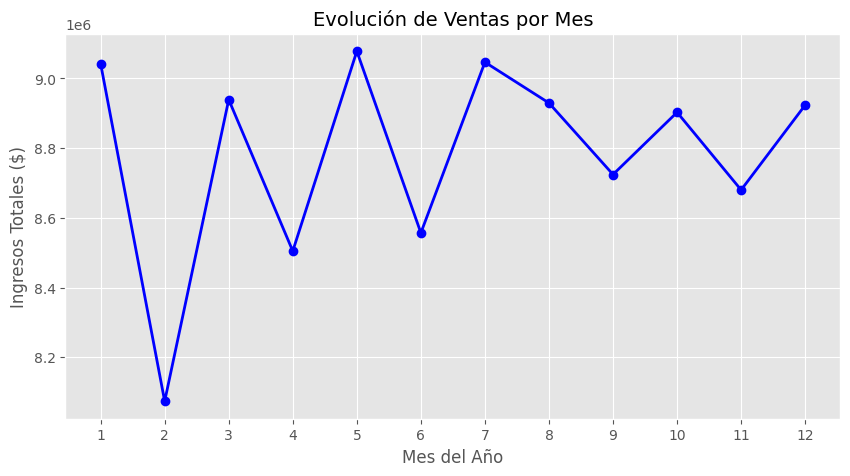

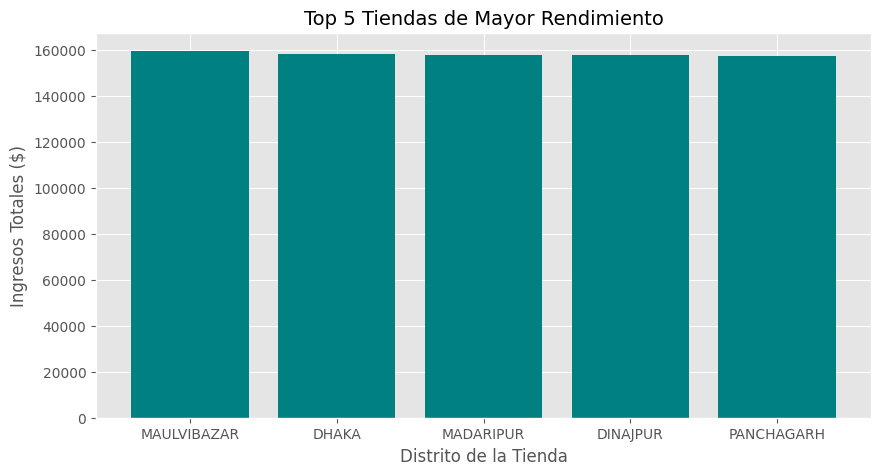

In [5]:
import matplotlib.pyplot as plt

# Configuración visual básica
plt.style.use('ggplot')

# 1. Gráfico de Líneas: Evolución de Ventas
plt.figure(figsize=(10, 5))
plt.plot(df_evolucion['Mes'].astype(str), df_evolucion['Ventas'], marker='o', color='b', linewidth=2)
plt.title('Evolución de Ventas por Mes', fontsize=14)
plt.xlabel('Mes del Año', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.grid(True)
plt.show()

print("\n")

# 2. Gráfico de Barras: Top 5 Tiendas por Distrito
plt.figure(figsize=(10, 5))
plt.bar(df_tiendas['Distrito'], df_tiendas['Ventas'], color='teal')
plt.title('Top 5 Tiendas de Mayor Rendimiento', fontsize=14)
plt.xlabel('Distrito de la Tienda', fontsize=12)
plt.ylabel('Ingresos Totales ($)', fontsize=12)
plt.show()

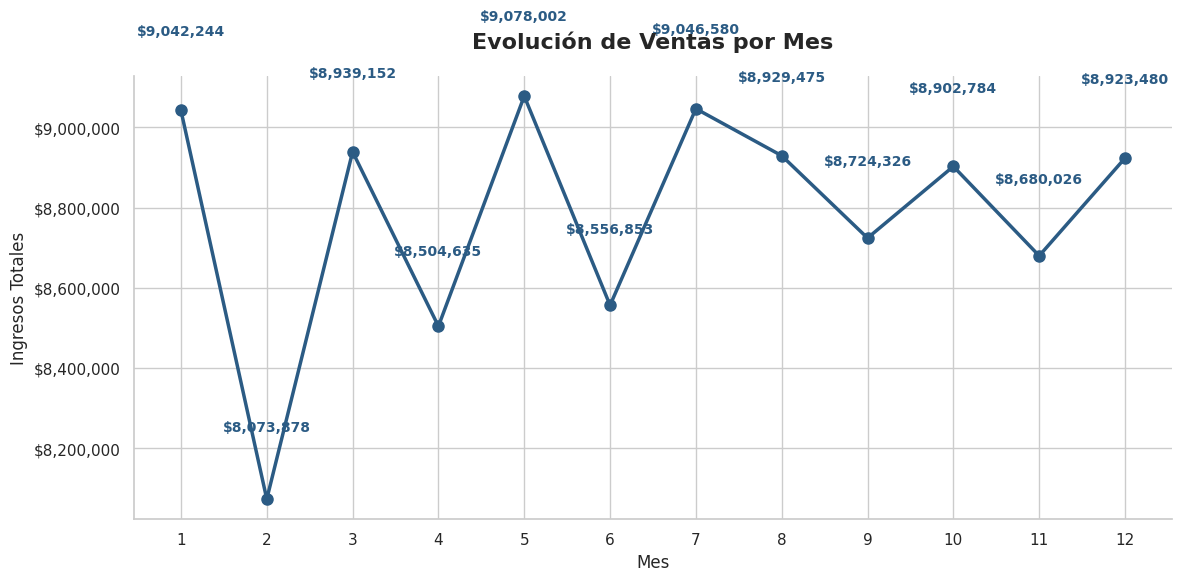

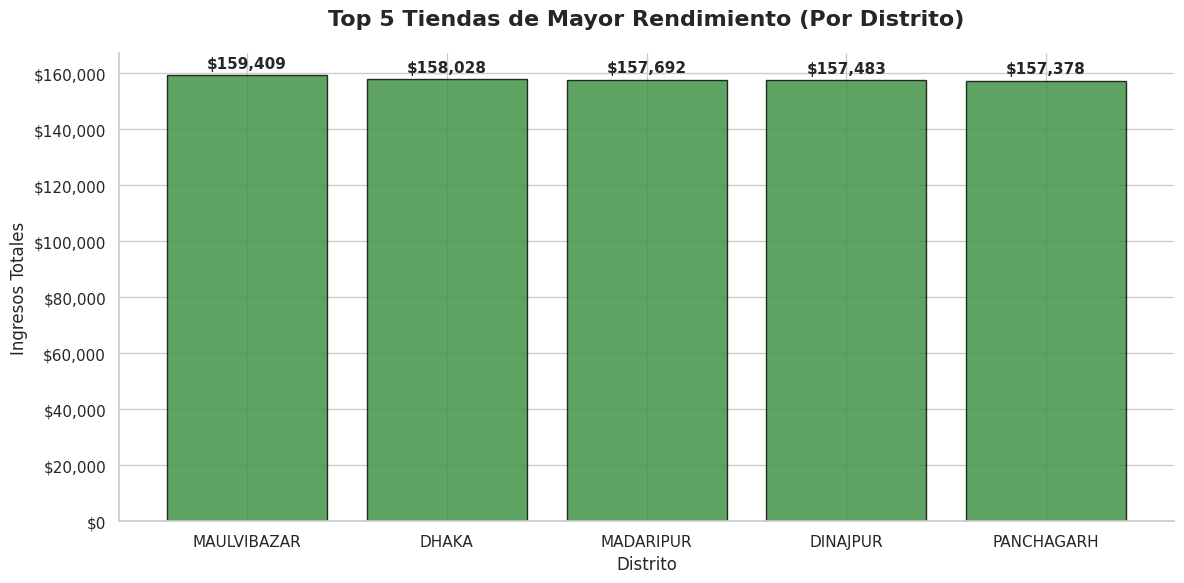

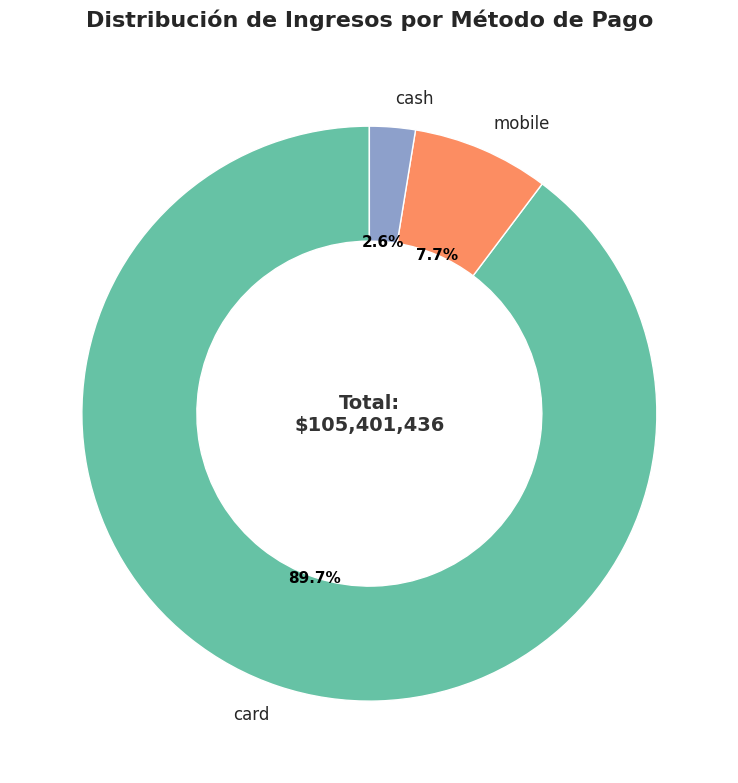

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Función para formatear el eje Y en moneda (ej. $1,000,000)
def formato_moneda(x, pos):
    return f'${x:,.0f}'
formatter = ticker.FuncFormatter(formato_moneda)

# 2. GRÁFICO DE LÍNEAS: Evolución de Ventas
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_evolucion['Mes'].astype(str), df_evolucion['Ventas'], marker='o', color='#2b5b84', linewidth=2.5, markersize=8)

ax.set_title('Evolución de Ventas por Mes', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ingresos Totales', fontsize=12)
ax.yaxis.set_major_formatter(formatter)

# Etiquetas de datos flotantes
for i, v in enumerate(df_evolucion['Ventas']):
    ax.text(i, v + (v*0.02), f'${v:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2b5b84')

sns.despine()
plt.tight_layout()
plt.show()

print("\n")

# 3. GRÁFICO DE BARRAS: Top 5 Tiendas
fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(df_tiendas['Distrito'], df_tiendas['Ventas'], color='#388e3c', edgecolor='black', alpha=0.8)

ax.set_title('Top 5 Tiendas de Mayor Rendimiento (Por Distrito)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Distrito', fontsize=12)
ax.set_ylabel('Ingresos Totales', fontsize=12)
ax.yaxis.set_major_formatter(formatter)

# Etiquetas de datos en las barras
for barra in barras:
    alto = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., alto + (alto*0.01), f'${alto:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

print("\n")

# 4. GRÁFICO DE DONA: Métodos de Pago
fig, ax = plt.subplots(figsize=(8, 8))
colores = sns.color_palette('Set2')[0:len(df_pagos)]

# Configuración de la dona (pie chart con un hueco en el centro)
wedges, texts, autotexts = ax.pie(
    df_pagos['Ventas'],
    labels=df_pagos['_id'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colores,
    wedgeprops=dict(width=0.4, edgecolor='w')
)

plt.setp(autotexts, size=11, weight="bold", color="black")
plt.setp(texts, size=12)
ax.set_title('Distribución de Ingresos por Método de Pago', fontsize=16, fontweight='bold', pad=20)

# Texto central del total
total_ventas = df_pagos['Ventas'].sum()
ax.text(0, 0, f'Total:\n${total_ventas:,.0f}', ha='center', va='center', fontsize=14, fontweight='bold', color='#333')

plt.tight_layout()
plt.show()

# **CONSUMO DE API PÚBLICA**

In [7]:
# (DummyJSON)
print("--- 6. CONSUMO API PÚBLICA ---")
respuesta = requests.get('https://dummyjson.com/products?limit=5')
if respuesta.status_code == 200:
    datos_api = respuesta.json()['products']
    df_api = pd.DataFrame(datos_api)[['id', 'title', 'price', 'category']]
    print(df_api)

--- 6. CONSUMO API PÚBLICA ---
   id                          title  price category
0   1  Essence Mascara Lash Princess   9.99   beauty
1   2  Eyeshadow Palette with Mirror  19.99   beauty
2   3                Powder Canister  14.99   beauty
3   4                   Red Lipstick  12.99   beauty
4   5                Red Nail Polish   8.99   beauty


# **DASHBOARD GERENCIAL**

In [8]:
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# 1. DISEÑO DE TARJETAS HTML PARA LOS KPIs
tarjetas_html = f"""
<div style="display: flex; gap: 20px; justify-content: space-between; font-family: 'Segoe UI', Arial, sans-serif; margin-bottom: 20px;">

    <div style="flex: 1; background: white; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 5px solid #2b5b84;">
        <p style="margin: 0; color: #6c757d; font-size: 14px; font-weight: bold; text-transform: uppercase;">Venta Total</p>
        <h2 style="margin: 10px 0 0 0; color: #2b5b84; font-size: 28px;">${kpis['Venta_Total']:,.0f}</h2>
    </div>

    <div style="flex: 1; background: white; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 5px solid #28a745;">
        <p style="margin: 0; color: #6c757d; font-size: 14px; font-weight: bold; text-transform: uppercase;">Transacciones</p>
        <h2 style="margin: 10px 0 0 0; color: #28a745; font-size: 28px;">{kpis['Numero_Transacciones']:,}</h2>
    </div>

    <div style="flex: 1; background: white; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 5px solid #ffc107;">
        <p style="margin: 0; color: #6c757d; font-size: 14px; font-weight: bold; text-transform: uppercase;">Ticket Promedio</p>
        <h2 style="margin: 10px 0 0 0; color: #ffc107; font-size: 28px;">${kpis['Ticket_Promedio']:,.2f}</h2>
    </div>

    <div style="flex: 1; background: white; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); border-top: 5px solid #17a2b8;">
        <p style="margin: 0; color: #6c757d; font-size: 14px; font-weight: bold; text-transform: uppercase;">Clientes Únicos</p>
        <h2 style="margin: 10px 0 0 0; color: #17a2b8; font-size: 28px;">{clientes_unicos:,}</h2>
    </div>

</div>
"""

# 2. GRÁFICOS INTERACTIVOS CON PLOTLY
# Gráfico de Líneas
fig_evolucion = px.line(df_evolucion, x='Mes', y='Ventas', title='📈 Evolución de Ventas por Mes', markers=True, color_discrete_sequence=['#2b5b84'])
fig_evolucion.update_layout(plot_bgcolor='rgba(0,0,0,0)', xaxis_title="Mes", yaxis_title="Ingresos ($)")

# Gráfico de Barras
fig_tiendas = px.bar(df_tiendas, x='Distrito', y='Ventas', title='🏪 Top 5 Tiendas (Distrito)', text_auto='.2s', color='Ventas', color_continuous_scale='Greens')
fig_tiendas.update_layout(plot_bgcolor='rgba(0,0,0,0)', xaxis_title="Distrito", yaxis_title="Ingresos ($)")

# Gráfico de Dona
fig_pagos = px.pie(df_pagos, values='Ventas', names='_id', hole=0.4, title='💳 Distribución por Método de Pago', color_discrete_sequence=px.colors.qualitative.Pastel)

# 3. MOSTRAR EL DASHBOARD EN COLAB
display(HTML(tarjetas_html))
fig_evolucion.show()
fig_tiendas.show()
fig_pagos.show()

# 4. EXPORTAR A UN ARCHIVO HTML ÚNICO PARA ENTREGAR
html_completo = f"""
<html>
<head><title>Dashboard Ejecutivo</title></head>
<body style="background-color: #f4f6f9; padding: 30px;">
    <h1 style="font-family: Arial; color: #333; text-align: center;">Dashboard Analítico - E-Commerce</h1>
    {tarjetas_html}
    <div style="display: flex; flex-direction: column; gap: 20px;">
        <div style="background: white; border-radius: 10px; padding: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">{fig_evolucion.to_html(full_html=False, include_plotlyjs='cdn')}</div>
        <div style="display: flex; gap: 20px;">
            <div style="flex: 1; background: white; border-radius: 10px; padding: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">{fig_tiendas.to_html(full_html=False, include_plotlyjs='cdn')}</div>
            <div style="flex: 1; background: white; border-radius: 10px; padding: 10px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">{fig_pagos.to_html(full_html=False, include_plotlyjs='cdn')}</div>
        </div>
    </div>
</body>
</html>
"""

# Guardar y descargar el archivo
with open('dashboard_ejecutivo.html', 'w', encoding='utf-8') as f:
    f.write(html_completo)

from google.colab import files
files.download('dashboard_ejecutivo.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>